In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

In [2]:
df = pd.read_csv("healthcare_priority_index.csv")

df.head()

,ranking,district,state,population,growth,sex_ratio,literacy,health_centres,population_per_health_centre,healthcare_density,...,female_literacy,antenatal_care,institutional_birth,vaccination,stunted,underweight,anaemia,healthcare_priority_score,priority_level,priority_rank
0,1,THANE,MAHARASHTRA,11060148.0,36.01 %,886,84.53,336.0,0.003315,Poor,...,0.151014,0.178949,0.081170,0.873284,0.747455,0.662894,0.627914,43.143000,Medium,72
1,2,NORTH TWENTY FOUR PARGANAS,WEST BENGAL,10009781.0,12.04 %,955,84.06,870.0,0.001090,Average,...,0.392507,0.241449,0.099746,0.146204,0.639949,0.644848,0.601030,28.488685,Low,430
2,3,BANGALORE,KARNATAKA,9621551.0,47.18 %,916,87.67,0.0,1.000000,Critical,...,0.203698,0.151220,0.008397,0.889742,0.626590,0.633849,0.295009,66.640940,High,1
3,4,PUNE,MAHARASHTRA,9429408.0,30.37 %,915,86.15,773.0,0.001162,Average,...,0.175229,0.189009,0.025827,0.788368,0.619466,0.682648,0.529387,38.714485,Low,161
4,5,MUMBAI SUBURBAN,MAHARASHTRA,9356962.0,8.29 %,860,89.91,0.0,0.972497,Critical,...,0.133181,0.166310,0.024427,0.146204,0.702545,0.596476,0.501359,54.229173,Medium,5


In [3]:
features = [

    "population",

    "health_centres",

    "population_per_health_centre",

    "literacy",

    "female_literacy",

    "vaccination",

    "anaemia",

    "stunted",

    "underweight",

    "institutional_birth",

    "antenatal_care"

]

X = df[features]

y = df["healthcare_priority_score"]

In [4]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42

)

In [5]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [6]:
rf = RandomForestRegressor(

n_estimators=300,

random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [7]:
xgb = XGBRegressor(

n_estimators=300,

learning_rate=0.05,

max_depth=6,

random_state=42

)

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

In [8]:
def evaluate_model(name,y_true,y_pred):

    print("="*50)

    print(name)

    print("="*50)

    print("MAE :",mean_absolute_error(y_true,y_pred))

    print("RMSE :",np.sqrt(mean_squared_error(y_true,y_pred)))

    print("R2 :",r2_score(y_true,y_pred))

    print()

In [9]:
evaluate_model("Linear Regression",y_test,pred_lr)

evaluate_model("Random Forest",y_test,pred_rf)

evaluate_model("XGBoost",y_test,pred_xgb)

Linear Regression
MAE : 4.510781547919652e-14
RMSE : 5.874362803940845e-14
R2 : 1.0

Random Forest
MAE : 1.3131447269908119
RMSE : 2.456402723683445
R2 : 0.90467716085157

XGBoost
MAE : 1.0813174180102005
RMSE : 1.9257418402308109
R2 : 0.9414139846167103



In [10]:
results = pd.DataFrame({

"Model":[

"Linear Regression",

"Random Forest",

"XGBoost"

],

"R2":[

r2_score(y_test,pred_lr),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_xgb)

]

})

results.sort_values(

"R2",

ascending=False

)

,Model,R2
0,Linear Regression,1.000000
2,XGBoost,0.941414
1,Random Forest,0.904677


In [11]:
importance = pd.DataFrame({

"Feature":features,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(

"Importance",

ascending=False

)

importance

,Feature,Importance
5,vaccination,0.523639
8,underweight,0.120650
2,population_per_health_centre,0.093560
6,anaemia,0.091879
7,stunted,0.058485
9,institutional_birth,0.043370
4,female_literacy,0.034695
10,antenatal_care,0.010588
3,literacy,0.010078
0,population,0.007188


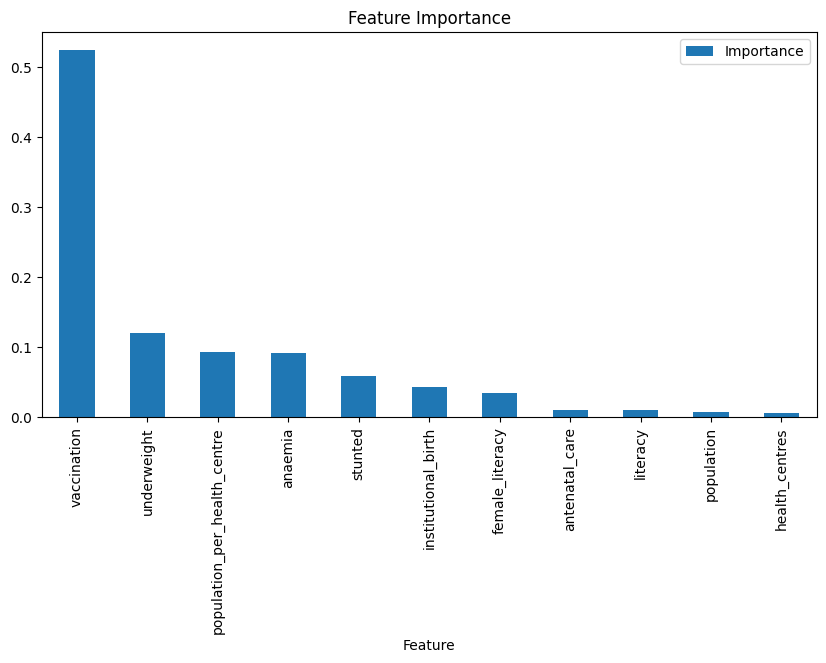

In [12]:
importance.plot.bar(

x="Feature",

y="Importance",

figsize=(10,5)

)

plt.title("Feature Importance")

plt.show()

In [14]:
joblib.dump(

xgb,

"healthcare_priority_model.pkl"

)

['healthcare_priority_model.pkl']

In [15]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Score :",prediction[0])

print("Actual Score :",y_test.iloc[0])

Predicted Score : 25.310048277042867
Actual Score : 23.86948859038511


In [16]:
predictions = X_test.copy()

predictions["Actual"] = y_test.values

predictions["Predicted"] = pred_rf

predictions.to_csv(

"model_predictions.csv",

index=False

)

predictions.head()

,population,health_centres,population_per_health_centre,literacy,female_literacy,vaccination,anaemia,stunted,underweight,institutional_birth,antenatal_care,Actual,Predicted
81,3529031.0,584.0,0.000522,71.09,0.455825,0.048566,0.597884,0.533461,0.535505,0.088931,0.100163,23.869489,25.310048
218,1889752.0,0.0,0.196323,68.82,0.491819,0.098445,0.472901,0.842875,0.786012,0.061069,0.141097,34.710908,34.461133
55,4021243.0,0.0,0.417880,60.56,0.617310,0.144336,0.543973,0.834351,0.721410,0.219211,0.318599,44.915895,39.717323
598,55626.0,5.0,0.001050,79.47,0.268325,0.897567,0.402545,0.546438,0.533049,0.000000,0.118272,36.748870,38.358588
264,1676276.0,278.0,0.000521,72.82,0.415740,0.027918,0.959960,0.635115,0.655953,0.109415,0.140091,31.210280,29.750103
